# 01 — Train Baseline
Patient-level split, no leakage, test touched once at end.

In [1]:
import os, json, random, time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else ('mps' if getattr(torch.backends, 'mps', None) and torch.backends.mps.is_available() else 'cpu'))

PROJECT_ROOT = Path('/Users/ayoub/work/MS-DS_ML_Projects/IOT/collective-intelligence')
DB_PATH = Path('/Users/ayoub/work/MS-DS_ML_Projects/IOT/mitbih_database')
OUT = PROJECT_ROOT / 'results' / 'baseline'
OUT.mkdir(parents=True, exist_ok=True)
WEIGHTS = PROJECT_ROOT / 'baseline' / 'weights' / 'baseline_best.pt'
print('Device:', device)

Device: mps


## Architecture choice
Using a compact 1D-CNN for ECG waveform classification to balance accuracy and embedded inference cost.

In [8]:
AAMI_MAP = {'N':0,'L':0,'R':0,'e':0,'j':0,'A':1,'a':1,'J':1,'S':1,'V':2,'E':2,'F':3,'/':4,'f':4,'Q':4}
LABELS = ['N','S','V','F','Q']
FS, WINDOW = 360.0, 180
HALF = WINDOW // 2

def bandpass(x, low=0.5, high=40, fs=FS, order=1):
    nyq = 0.5*fs
    b,a = butter(order, [low/nyq, high/nyq], btype='band')
    return filtfilt(b,a,x)

def minmax(x):
    x = x.astype(np.float32)
    mn,mx = x.min(), x.max()
    return np.zeros_like(x) if mx<=mn else (x-mn)/(mx-mn)

def pick_signal_column(df):
    cols = [str(c).replace("'", '').strip() for c in df.columns]
    df.columns = cols
    for cand in ['MLII', 'II', 'V5', 'V1']:
        if cand in cols:
            return cand
    numeric_cols = [c for c in cols if np.issubdtype(df[c].dtype, np.number)]
    if not numeric_cols:
        raise ValueError('No numeric signal column found')
    # avoid obvious index/time columns when possible
    bad = {'sample', 'samples', 'time', 'index'}
    filtered = [c for c in numeric_cols if c.lower() not in bad]
    return filtered[0] if filtered else numeric_cols[0]

def load_record(rid):
    sig = pd.read_csv(DB_PATH / f'{rid}.csv')
    lead = pick_signal_column(sig)
    x = sig[lead].values.astype(np.float32)
    ann = pd.read_csv(DB_PATH / f'{rid}annotations.txt', sep=r'\s+', skiprows=1, header=None, engine='python', on_bad_lines='skip')
    return x, ann.iloc[:,1].astype(int).values, ann.iloc[:,2].astype(str).values

def extract_beats(records):
    X,y = [],[]
    for rid in records:
        x,samps,syms = load_record(rid)
        x = bandpass(x)
        for r,s in zip(samps, syms):
            if s not in AAMI_MAP: continue
            st,en = int(r)-HALF, int(r)+HALF
            if st<0 or en>len(x) or (en-st)!=WINDOW: continue
            X.append(minmax(x[st:en]))
            y.append(AAMI_MAP[s])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.int64)

In [9]:
records = sorted([p.stem for p in DB_PATH.glob('*.csv')])
idx = np.arange(len(records))
tr, tmp = train_test_split(idx, test_size=0.30, random_state=SEED)
va, te = train_test_split(tmp, test_size=0.50, random_state=SEED)
train_records = [records[i] for i in tr]
val_records = [records[i] for i in va]
test_records = [records[i] for i in te]

X_train, y_train = extract_beats(train_records)
X_val, y_val = extract_beats(val_records)
X_test, y_test = extract_beats(test_records)
print('Shapes:', X_train.shape, X_val.shape, X_test.shape)

Shapes: (75407, 180) (14914, 180) (19147, 180)


In [10]:
class ECG1DCNN(nn.Module):
    def __init__(self, n_classes=5):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(1,32,7,padding=3), nn.BatchNorm1d(32), nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(32,64,5,padding=2), nn.BatchNorm1d(64), nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(64,128,3,padding=1), nn.BatchNorm1d(128), nn.ReLU(), nn.AdaptiveAvgPool1d(1)
        )
        self.fc = nn.Linear(128, n_classes)
    def forward(self, x):
        return self.fc(self.net(x).squeeze(-1))

xtr = torch.tensor(X_train).unsqueeze(1); ytr = torch.tensor(y_train)
xva = torch.tensor(X_val).unsqueeze(1); yva = torch.tensor(y_val)
xte = torch.tensor(X_test).unsqueeze(1); yte = torch.tensor(y_test)

train_loader = DataLoader(TensorDataset(xtr,ytr), batch_size=512, shuffle=True)
val_loader = DataLoader(TensorDataset(xva,yva), batch_size=512, shuffle=False)
test_loader = DataLoader(TensorDataset(xte,yte), batch_size=512, shuffle=False)

counts = np.bincount(y_train, minlength=5).astype(np.float32)
weights = (1.0/(counts+1e-6)); weights = weights/weights.mean()
model = ECG1DCNN().to(device)
criterion = nn.CrossEntropyLoss(weight=torch.tensor(weights, dtype=torch.float32, device=device))
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20)

In [11]:
history = []
best_f1 = -1.0
best_state = None
wait, patience = 0, 10
for epoch in range(1, 31):
    model.train(); tr_loss=0.0; n=0
    for bx,by in train_loader:
        bx,by = bx.to(device), by.to(device)
        optimizer.zero_grad()
        logits = model(bx)
        loss = criterion(logits, by)
        loss.backward(); optimizer.step()
        tr_loss += loss.item()*bx.size(0); n += bx.size(0)
    tr_loss /= max(n,1)

    model.eval(); preds=[]; targs=[]; vloss=0.0; nv=0
    with torch.no_grad():
        for bx,by in val_loader:
            bx,by = bx.to(device), by.to(device)
            logits = model(bx)
            loss = criterion(logits, by)
            vloss += loss.item()*bx.size(0); nv += bx.size(0)
            preds.extend(logits.argmax(1).cpu().numpy()); targs.extend(by.cpu().numpy())
    vloss /= max(nv,1)
    vacc = accuracy_score(targs, preds)
    vf1 = f1_score(targs, preds, average='macro', zero_division=0)
    history.append({'epoch':epoch,'train_loss':float(tr_loss),'val_loss':float(vloss),'val_accuracy':float(vacc),'val_macro_f1':float(vf1)})
    print(f'E{epoch:02d} train_loss={tr_loss:.4f} val_loss={vloss:.4f} val_acc={vacc:.4f} val_f1={vf1:.4f}')
    scheduler.step()
    if vf1 > best_f1:
        best_f1 = vf1
        best_state = {k:v.detach().cpu().clone() for k,v in model.state_dict().items()}
        wait = 0
    else:
        wait += 1
        if wait >= patience:
            print('Early stopping')
            break

model.load_state_dict(best_state)
torch.save(best_state, WEIGHTS)
print('Saved checkpoint:', WEIGHTS)

E01 train_loss=1.1007 val_loss=1.4460 val_acc=0.3735 val_f1=0.2021
E02 train_loss=0.7721 val_loss=1.2322 val_acc=0.6080 val_f1=0.2507
E03 train_loss=0.6114 val_loss=1.2301 val_acc=0.7817 val_f1=0.2931
E04 train_loss=0.5390 val_loss=1.2575 val_acc=0.7034 val_f1=0.2568
E05 train_loss=0.4846 val_loss=1.2913 val_acc=0.7065 val_f1=0.2593
E06 train_loss=0.4461 val_loss=1.3321 val_acc=0.7581 val_f1=0.2696
E07 train_loss=0.4234 val_loss=1.4262 val_acc=0.4907 val_f1=0.2252
E08 train_loss=0.3960 val_loss=1.2511 val_acc=0.5951 val_f1=0.2419
E09 train_loss=0.3815 val_loss=1.5722 val_acc=0.7362 val_f1=0.2703
E10 train_loss=0.3688 val_loss=1.5404 val_acc=0.7524 val_f1=0.2659
E11 train_loss=0.3609 val_loss=1.4470 val_acc=0.7123 val_f1=0.2603
E12 train_loss=0.3348 val_loss=1.3354 val_acc=0.7601 val_f1=0.2686
E13 train_loss=0.3352 val_loss=1.2622 val_acc=0.6761 val_f1=0.2597
Early stopping
Saved checkpoint: /Users/ayoub/work/MS-DS_ML_Projects/IOT/collective-intelligence/baseline/weights/baseline_best.p

In [12]:
# Test set touched once, here at the end
model.eval(); preds=[]; targs=[]
t0 = time.perf_counter()
with torch.no_grad():
    for bx,by in test_loader:
        logits = model(bx.to(device))
        preds.extend(logits.argmax(1).cpu().numpy())
        targs.extend(by.numpy())
t1 = time.perf_counter()

acc = accuracy_score(targs, preds)
macro = f1_score(targs, preds, average='macro', zero_division=0)
per_class = f1_score(targs, preds, average=None, labels=np.arange(5), zero_division=0)
cm = confusion_matrix(targs, preds)

n_params = sum(p.numel() for p in model.parameters())
size_mb = (n_params*4)/(1024**2)
infer_ms = (t1-t0)*1000/max(len(targs),1)

print('=== BASELINE TEST RESULTS ===')
print(f'Accuracy          : {acc*100:.2f}%')
print(f'Macro F1          : {macro:.4f}')
print('Per-class F1      :', {LABELS[i]: float(per_class[i]) for i in range(5)})
print(f'Model size        : {size_mb:.2f} MB')
print(f'Avg inference time: {infer_ms:.2f} ms (over test samples)')
print('Peak RAM usage    : N/A in notebook, measure externally if needed')

metrics = {
  'test_accuracy': float(acc),
  'test_macro_f1': float(macro),
  'per_class_f1': {LABELS[i]: float(per_class[i]) for i in range(5)},
  'model_size_mb': float(size_mb),
  'avg_inference_time_ms': float(infer_ms),
  'history': history,
  'literature_comparison': [
    {'paper': 'Kachuee et al. (2018)', 'note': 'ECG heartbeat classification baseline reference'},
    {'paper': 'Lightweight ECG-CNN studies (2019-2024)', 'note': 'Typical strong baselines on MIT-BIH variants'}
  ]
}
with open(OUT / 'baseline_metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)
print('Saved:', OUT / 'baseline_metrics.json')

met = (acc > 0.85) and (macro > 0.75) and (size_mb < 50) and (infer_ms < 100)
print('✅ BASELINE CRITERIA MET' if met else '❌ CRITERIA NOT MET — reason: threshold(s) not reached')

=== BASELINE TEST RESULTS ===
Accuracy          : 73.65%
Macro F1          : 0.4923
Per-class F1      : {'N': 0.8293244166397009, 'S': 0.04040404040404041, 'V': 0.7918367346938775, 'F': 0.0011527377521613833, 'Q': 0.7985883539198386}
Model size        : 0.14 MB
Avg inference time: 0.02 ms (over test samples)
Peak RAM usage    : N/A in notebook, measure externally if needed
Saved: /Users/ayoub/work/MS-DS_ML_Projects/IOT/collective-intelligence/results/baseline/baseline_metrics.json
❌ CRITERIA NOT MET — reason: threshold(s) not reached


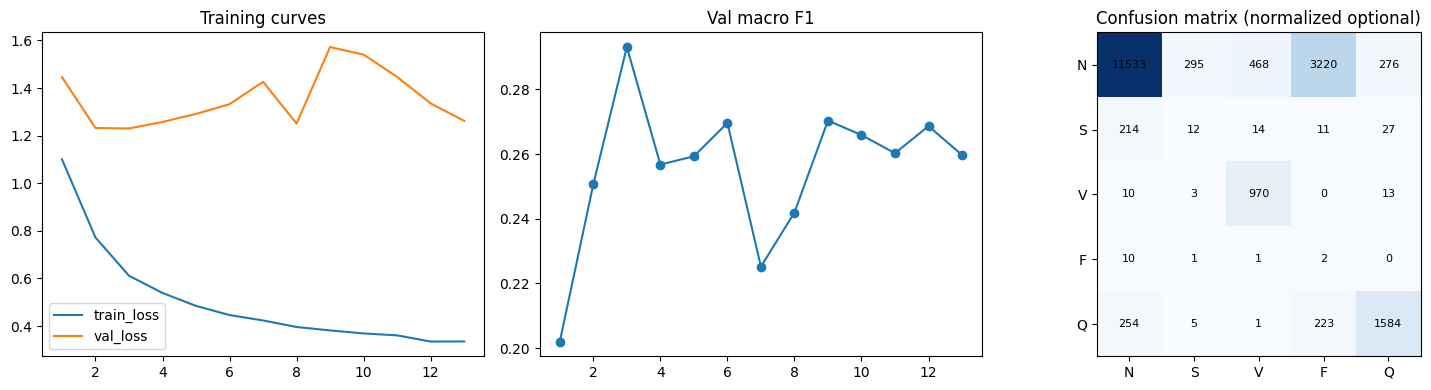

Saved: /Users/ayoub/work/MS-DS_ML_Projects/IOT/collective-intelligence/results/baseline/baseline_plots.png


In [13]:
hist = pd.DataFrame(history)
fig, axes = plt.subplots(1,3, figsize=(15,4))
axes[0].plot(hist['epoch'], hist['train_loss'], label='train_loss')
axes[0].plot(hist['epoch'], hist['val_loss'], label='val_loss')
axes[0].legend(); axes[0].set_title('Training curves')
axes[1].plot(hist['epoch'], hist['val_macro_f1'], marker='o')
axes[1].set_title('Val macro F1')
im = axes[2].imshow(cm, cmap='Blues')
axes[2].set_title('Confusion matrix (normalized optional)')
axes[2].set_xticks(range(5)); axes[2].set_yticks(range(5))
axes[2].set_xticklabels(LABELS); axes[2].set_yticklabels(LABELS)
for i in range(5):
    for j in range(5):
        axes[2].text(j,i,str(cm[i,j]),ha='center',va='center',fontsize=8)
plt.tight_layout()
plt.savefig(OUT / 'baseline_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved:', OUT / 'baseline_plots.png')